In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


STEP 1: BETA CALCULATION
                                         Variable                 Formula   Value
                       MPS Limited Unlevered Beta    βL / (1 + (1-T)*D/E)  0.5318
                             Affle Unlevered Beta    βL / (1 + (1-T)*D/E)  0.3172
                            Newgen Unlevered Beta    βL / (1 + (1-T)*D/E)  0.4979
Silver Touch Technologies Limited  Unlevered Beta    βL / (1 + (1-T)*D/E) -0.2161
             Ksolves India Limited Unlevered Beta    βL / (1 + (1-T)*D/E) -0.4165
                           Average Unlevered Beta                Mean(βU)  0.1429
                                   Relevered Beta βU*(1+(1-T)*Target D/E)  0.1482

STEP 2: COST OF CAPITAL
                    Variable                       Formula  Value
         Cost of Equity (Re)                 Rf + β(Rm-Rf) 0.0796
           Cost of Debt (Rd)           Net Interest / Debt 0.2612
Net Debt Equity Ratio (FY25)                           D/E 0.0500
                           E 

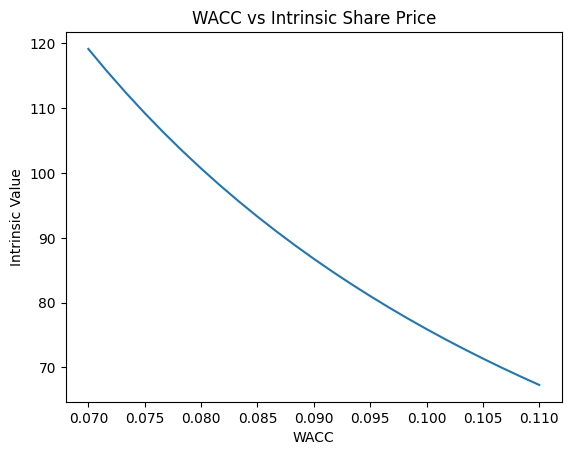

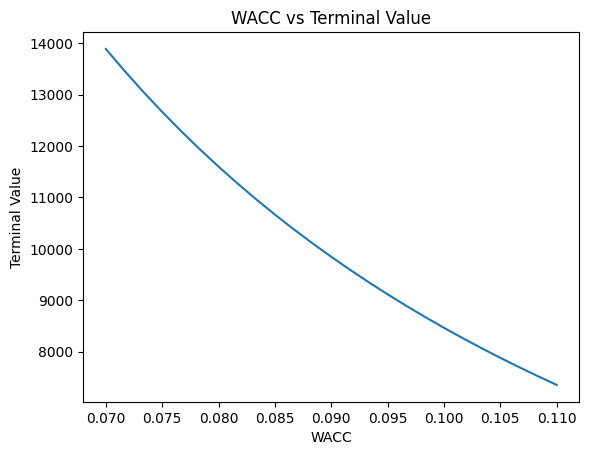

In [ ]:
# ==========================================================
# UTILITY: TABLE PRINTER
# ==========================================================
def print_table(title, df):
    print(f"\n{'='*75}")
    print(f"{title}")
    print(f"{'='*75}")
    print(df.to_string(index=False))


# ==========================================================
# STEP 1: BETA MODEL
# ==========================================================
class BetaModel:
    def __init__(self, peers, tax_rate, target_de):
        self.tax_rate = tax_rate
        self.target_de = target_de
        self.peers = peers

        self.unlevered_betas = []
        for p in peers:
            beta_u = p['levered_beta'] / (1 + (1 - tax_rate) * p['de'])
            self.unlevered_betas.append(beta_u)

        self.avg_unlevered = np.mean(self.unlevered_betas)
        self.relevered_beta = self.avg_unlevered * (1 + (1 - tax_rate) * target_de)

        self.print_audit()

    def print_audit(self):
        rows = []
        for i, p in enumerate(self.peers):
            rows.append([
                f"{p['name']} Unlevered Beta",
                "βL / (1 + (1-T)*D/E)",
                round(self.unlevered_betas[i],4)
            ])
        rows.append(["Average Unlevered Beta","Mean(βU)", round(self.avg_unlevered,4)])
        rows.append(["Relevered Beta","βU*(1+(1-T)*Target D/E)", round(self.relevered_beta,4)])

        df = pd.DataFrame(rows, columns=["Variable","Formula","Value"])
        print_table("STEP 1: BETA CALCULATION", df)


# ==========================================================
# STEP 2: COST OF CAPITAL
# ==========================================================
class CostOfCapital:
    def __init__(self, rf, rm, beta,interest_Income,interest_paid,Borrowings_Non_current_liabilities,Lease_liabilities_Non_current_liabilities,Borrowings_current_liabilities,Lease_liabilities_current_liabilities, net_interest, total_debt, tax, Net_Debt_Equity_Ratio_FY25):
        self.rf = rf
        self.rm = rm
        self.beta = beta
        self.tax = tax

        net_interest=interest_Income+interest_paid
        total_debt=Borrowings_Non_current_liabilities+Lease_liabilities_Non_current_liabilities+Borrowings_current_liabilities+Lease_liabilities_current_liabilities

        self.net_interest=net_interest
        self.total_debt=total_debt

        self.re = rf + beta * (rm - rf)
        self.rd = abs(self.net_interest) / self.total_debt

        self.Net_Debt_Equity_Ratio_FY25=Net_Debt_Equity_Ratio_FY25
        

        self.wacc =(20/21)*self.re + (1/21)*self.rd*(1-tax)

        self.print_audit()

    def print_audit(self):
        rows = [
            ["Cost of Equity (Re)", "Rf + β(Rm-Rf)", round(self.re,4)],
            ["Cost of Debt (Rd)", "Net Interest / Debt", round(self.rd,4)],
            ["Net Debt Equity Ratio (FY25)","D/E", round(self.Net_Debt_Equity_Ratio_FY25,4)],
            ["E","20D"],
            ["WACC","(E/E+D)*Re + (D/E+D)*Rd*(1-T)", round(self.wacc,4)]
        ]
        df = pd.DataFrame(rows, columns=["Variable","Formula","Value"])
        print_table("STEP 2: COST OF CAPITAL", df)


# ==========================================================
# STEP 3: CASH FLOW ENGINE
# ==========================================================
class CashFlowEngine:
    def __init__(self, revenue, operating_cost, da, capex,
                 nwc_2024, nwc_2025,
                 prov_2024, prov_2025,
                 tax_rate):
        self.da=da
        self.ebit = revenue - operating_cost-self.da
        self.ebitda = self.ebit + self.da

        self.delta_nwc = nwc_2025 - nwc_2024
        self.delta_prov = prov_2025 - prov_2024

        self.pre_tax_fcf = (
            self.ebitda
            - self.delta_nwc
            - capex
            - self.delta_prov
        )

        self.tax_adjusted = self.ebit * tax_rate
        self.fcff = self.pre_tax_fcf - self.tax_adjusted

        self.print_main_audit()

    def print_main_audit(self):
        rows = [
            ["Depreciation & Amortisation","1/5(Goodwill+other intangiable assets)+1/8(Property,plant and equipment+right-of-use assets)", round(self.da,2)],
            ["EBIT","Revenue - Operating Cost", round(self.ebit,2)],
            ["EBITDA","EBIT + D&A", round(self.ebitda,2)],
            ["ΔNWC","NWC25 - NWC24", round(self.delta_nwc,2)],
            ["ΔProvisions","Prov25 - Prov24", round(self.delta_prov,2)],
            ["Pre-Tax FCF","EBITDA - ΔNWC - CAPEX - ΔProv", round(self.pre_tax_fcf,2)],
            ["Tax Adjustment","EBIT * Tax", round(self.tax_adjusted,2)],
            ["FCFF","PreTax FCF - Taxes", round(self.fcff,2)]
        ]
        df = pd.DataFrame(rows, columns=["Variable","Formula","Value"])
        print_table("STEP 3: CASH FLOW BUILD-UP", df)


# ==========================================================
# STEP 4: MULTI-STAGE DCF
# ==========================================================
class DCFModel:
    def __init__(self, fcff_base, growth_rates, wacc, terminal_g, verbose=True):

        self.wacc = wacc
        self.growth_rates = growth_rates
        self.verbose= verbose

        self.fcffs = []
        self.discounted = []

        prev = fcff_base
        for i, g in enumerate(growth_rates):
            new = prev * (1 + g)
            self.fcffs.append(new)
            discount = new / ((1+wacc)**(i+1))
            self.discounted.append(discount)
            prev = new

        self.sum_pv = sum(self.discounted)

        # Terminal
        self.fcff_terminal = self.fcffs[-1] * (1 + terminal_g)
        self.terminal_value = (self.fcff_terminal/self.wacc) / ((1+self.wacc)**5)
        self.discounted_tv = self.terminal_value / ((1+self.wacc)**len(growth_rates))

        self.enterprise_value = self.sum_pv + self.discounted_tv

        if self.verbose:
            self.print_projection()

    def print_projection(self):
        df = pd.DataFrame({
            "Year": range(1,len(self.fcffs)+1),
            "Growth": self.growth_rates,
            "FCFF": np.round(self.fcffs,2),
            "Discounted CF": np.round(self.discounted,2)
        })
        df1=pd.DataFrame([
            ["fcff_terminal","FCFF5(1-TErminal Growth Rate(g))",round(self.fcff_terminal,2)],
            ["Terminal Value","(FCFF6/WACC)/((1+WACC)^5)",round(self.terminal_value,2)],
            ["Discounted Terminal Value","Terminal Value/(1+WACC)^6",round(self.discounted_tv,2)]
        ], columns=["Variable","Formula","Value"])
        print_table("STEP 4: PROJECTION & DISCOUNTING", df)
        print_table("STEP 5: TERMINAL VALUE",df1)


# ==========================================================
# STEP 5: EQUITY VALUE
# ==========================================================
def equity_valuation(ev, debt, shares, price):
    equity_value = ev - debt
    intrinsic = equity_value / shares
    upside = (intrinsic - price)/price * 100

    df = pd.DataFrame([
        ["Enterprise Value","Σ PV + PV(TV)", round(ev,2)],
        ["Equity Value","EV - Debt", round(equity_value,2)],
        ["Intrinsic Value","Equity / Shares", round(intrinsic,2)],
        ["Upside %","(IV-Price)/Price", round(upside,2)]
    ], columns=["Variable","Formula","Value"])

    print_table("STEP 6: EQUITY VALUATION", df)

    return intrinsic


# ==========================================================
# WACC SENSITIVITY VISUALS
# ==========================================================
def sensitivity_visual(base_fcff, growth_rates, terminal_g, debt, shares):

    wacc_range = np.linspace(0.07,0.11,25)
    intrinsic_values = []
    terminal_values = []

    for w in wacc_range:
        dcf = DCFModel(base_fcff, growth_rates, w, terminal_g,verbose=False)
        ev = dcf.enterprise_value
        intrinsic = (ev - debt)/shares
        intrinsic_values.append(intrinsic)
        terminal_values.append(dcf.terminal_value)

    plt.figure()
    plt.plot(wacc_range, intrinsic_values)
    plt.title("WACC vs Intrinsic Share Price")
    plt.xlabel("WACC")
    plt.ylabel("Intrinsic Value")
    plt.show()

    plt.figure()
    plt.plot(wacc_range, terminal_values)
    plt.title("WACC vs Terminal Value")
    plt.xlabel("WACC")
    plt.ylabel("Terminal Value")
    plt.show()


# ==========================================================
# ------------------- EXECUTION ----------------------------
# ==========================================================

peers = [
    {'name': 'MPS Ltd', 'levered_beta': 0.54, 'debt_to_equity_ratio': 0.0206},
    {'name': 'Ksolves India Limited', 'levered_beta': 1.03, 'debt_to_equity_ratio': 0.0753},
    {'name': 'Silver Touch Technologies Ltd', 'levered_beta': 0.78, 'debt_to_equity_ratio': 0.2340},
    {'name': 'Sasken Technologies Ltd', 'levered_beta': 0.85, 'debt_to_equity_ratio': 0.0320},
    {'name': 'InfoBeans Technologies Ltd', 'levered_beta': 0.92, 'debt_to_equity_ratio': 0.0410},
    {'name': 'Zensar Technologies Limited', 'levered_beta': 1.15, 'debt_to_equity_ratio': 0.0285},
    {'name': 'Sonata Software Limited', 'levered_beta': 1.21, 'debt_to_equity_ratio': 0.4210},
    {'name': 'Happiest Minds Technologies', 'levered_beta': 1.08, 'debt_to_equity_ratio': 0.2830},
    {'name': 'Coforge Limited', 'levered_beta': 1.32, 'debt_to_equity_ratio': 0.1120},
    {'name': 'Affle India', 'levered_beta': 0.32, 'debt_to_equity_ratio': 0.0118},
    {'name': 'Newgen Software', 'levered_beta': 0.51, 'debt_to_equity_ratio': 0.0325}
]

beta_model = BetaModel(peers,0.25,0.05)

cost_model = CostOfCapital(
    rf=0.065,
    rm=0.135,
    beta=beta_model.relevered_beta,
    interest_Income=137.45,
    interest_paid=-45.7,
    Borrowings_Non_current_liabilities=0,
    Lease_liabilities_Non_current_liabilities =62.77,
    Borrowings_current_liabilities =265.89,
    Lease_liabilities_current_liabilities =22.64,
    net_interest=0.0,
    total_debt=0.0,
    tax=0.25,
    Net_Debt_Equity_Ratio_FY25=0.05
)

cashflow = CashFlowEngine(
    revenue=2488,
    operating_cost=1846.85,
    da=98.64075,
    capex=-140.07,
    nwc_2024=179.72,
    nwc_2025=222.59,
    prov_2024=315.52,
    prov_2025=305.65,
    tax_rate=0.25
)

growths = [0.18,0.16,0.14,0.11,0.08]
dcf = DCFModel(cashflow.fcff,growths,cost_model.wacc,0.06)

intrinsic = equity_valuation(
    dcf.enterprise_value,
    181.79,
    115.084164,
    120
)

sensitivity_visual(
    cashflow.fcff,
    growths,
    0.06,
    181.79,
    115.084164
)
